<a href="https://colab.research.google.com/github/maoyuqing50-code/Wiki-Trends-Analysis/blob/main/wikipedia_analysis_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/maoyuqing50-code/tryaimama/blob/main/wikipedia_analysis_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wikipedia EN — Linguistic Analysis (v4)
### IS-618 · University of Mannheim

**What this notebook does:**
1. Loads pre-matched contested/stable article pairs from `final_pairs_en_strict.json`
2. Extracts **7 linguistic features** across Layer 1 (F1–F2), Layer 2 (F3–F5), Layer 3 (F6–F7)
3. Runs **Wilcoxon signed-rank tests** on matched pairs with Holm correction (with r_rb effect size)
4. Runs **logistic regression** with topic controls
5. Produces **Bootstrap 95% CI**, VIF check, coefficient plot, Spearman correlation heatmap
6. Reports **F8** (NLI sentence-level bias density) separately as an auxiliary robustness check

**Feature map:**
| ID  | Feature                          | Layer | Direction |
|-----|----------------------------------|-------|-----------|
| F1  | Epistemic hedge density          | L1    | C > S     |
| F2  | Affective stance marker density  | L1    | C > S     |
| F3  | Weasel word density              | L2    | C > S     |
| F4  | Attribution verb bias ratio      | L2    | C > S     |
| F5  | Entailment word density (LLM)    | L2    | C > S     |
| F6  | Contrastive transition density   | L3    | C > S     |
| F7  | Lexical diversity (MTLD)         | L3    | C > S     |

**F8** (Sentence-level bias density, NLI) is auxiliary only — not included in main tests.

**File needed:** `final_pairs_en_strict.json`


## 0. Install Dependencies

In [1]:
# Run this cell first — takes ~3 minutes
!pip install -q lexicalrichness statsmodels transformers torch spacy seaborn requests
!python -m spacy download en_core_web_sm -q
print('Done')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 110.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Done


## 0b. Mount Google Drive & Set Checkpoint Paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/wiki_project/checkpoints/'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

F5_CHECKPOINT = CHECKPOINT_DIR + 'f5_entailment_scores.csv'
F8_CHECKPOINT = CHECKPOINT_DIR + 'f8_bias_scores.csv'
print(f'Checkpoint dir: {CHECKPOINT_DIR}')


Mounted at /content/drive
Checkpoint dir: /content/drive/MyDrive/wiki_project/checkpoints/


## 1. Imports

In [3]:
import json, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.stats as stats
warnings.filterwarnings('ignore')

from collections import Counter
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.utils import resample
from lexicalrichness import LexicalRichness

import spacy
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])
nlp.add_pipe('sentencizer')
print('Imports OK | spaCy loaded')


Imports OK | spaCy loaded


## ⚠️ Before running
Upload `final_pairs_en_strict.json` to this Colab session.
Drag-and-drop to the Files panel on the left, or run:
```python
from google.colab import files
files.upload()
```


## 1b. Load Pre-Matched Pairs

In [4]:
with open('final_pairs_en_strict.json', encoding='utf-8') as f:
    pairs = json.load(f)

records = []
for p in pairs:
    for role, art in [('contested', p['contested']), ('stable', p['stable'])]:
        records.append({
            'title'     : art['title'],
            'label'     : art['label'],        # 0=contested, 1=stable
            'text'      : art['clean_text'],
            'topic'     : art['topic'],
            'word_count': art['word_count'],
            'age_days'  : art['age_days'],
            'pair_id'   : p['contested']['title'],
        })
df = pd.DataFrame(records)
print(f'Total articles : {len(df)}')
print(f'Labels         : {df.label.value_counts().to_dict()}')
print(f'Topics         : {df.topic.value_counts().to_dict()}')


Total articles : 286
Labels         : {0: 143, 1: 143}
Topics         : {'geography': 76, 'science': 76, 'culture': 74, 'politics_history': 60}


## 2. Word Lists & Feature Functions

In [47]:
# ══════════════════════════════════════════════════════════════════════════════
# WORD LISTS
# ══════════════════════════════════════════════════════════════════════════════

# ── F1: Epistemic Hedge Density ────────────────────────────────────────────────
# Hyland (2018, pp. 271–272) Appendix
# claim/claimed/claims and argue/argued/argues removed to avoid
# double-counting with F4 BIASED_REPORT and NEUTRAL_REPORT
HEDGES = [
    # ── Modal auxiliaries — epistemic possibility/necessity ──────────────────
    'could', "couldn't", 'may', 'might', 'ought', 'should', 'would',

    # ── Epistemic verbs — express writer's uncertain judgment ────────────────
    'appear', 'appeared', 'appears',
    'assume', 'assumed',
    'doubt',
    'estimate', 'estimated',
    'feel', 'feels', 'felt',
    'guess',
    'indicate', 'indicated', 'indicates',
    'postulate', 'postulated', 'postulates',
    'seem', 'seems',
    'suggest', 'suggested', 'suggests',
    'suppose', 'supposed', 'supposes',
    'suspect', 'suspects',
    'tend to', 'tended to', 'tends to',

    # ── Probability adverbs/adjectives — signal degree of certainty ──────────
    'apparently',
    'doubtful',
    'likely',
    'maybe',
    'perhaps',
    'plausible', 'plausibly',
    'possible', 'possibly',
    'presumable', 'presumably',
    'probable', 'probably',
    'uncertain', 'uncertainly',
    'unclear', 'unclearly',
    'unlikely',

    # ── Perspective markers — attribute proposition to writer's view ─────────
    'from my perspective', 'from our perspective', 'from this perspective',
    'in my opinion', 'in my view', 'in this view',
    'in our opinion', 'in our view',
    'to my knowledge',
]

# ── F2: Affective Stance Marker Density ───────────────────────────────────────
# Hyland (2018, pp. 268–269) attitude markers UNION MPQA strong subjectives
# (Riloff & Wiebe 2003) via Recasens et al. (2013)
# 'essentially' removed to avoid double-counting with F1 HEDGES
AFFECTIVE_MARKERS = [
    'admittedly',
    'agree', 'agreed', 'agrees',
    'amazed', 'amazing', 'amazingly',
    'appropriate', 'appropriately',
    'astonished', 'astonishing', 'astonishingly',
    'correctly',
    'curious', 'curiously',
    'desirable', 'desirably',
    'disappointed', 'disappointing', 'disappointingly',
    'disagree', 'disagreed', 'disagrees',
    'dramatic', 'dramatically',
    'essential',
    'expected', 'expectedly',
    'fortunate', 'fortunately',
    'hopeful', 'hopefully',
    'important', 'importantly',
    'inappropriate', 'inappropriately',
    'interesting', 'interestingly',
    'prefer', 'preferable', 'preferably', 'preferred',
    'remarkable', 'remarkably',
    'shocked', 'shocking', 'shockingly',
    'striking', 'strikingly',
    'surprised', 'surprising', 'surprisingly',
    'unbelievable', 'unbelievably',
    'understandable', 'understandably',
    'unexpected', 'unexpectedly',
    'unfortunate', 'unfortunately',
    'unusual', 'unusually',
    # ── MPQA strong subjectives (Riloff & Wiebe 2003) — high-confidence subset
    # Source: Recasens et al. (2013) operationalisation of MPQA lexicon
    'brutal', 'deplorable', 'fraudulent', 'atrocious', 'outrageous',
    'condemn', 'manipulate', 'suppress', 'persecute', 'exploit',
    'shameful', 'disgraceful', 'corrupt', 'vicious', 'appalling',
    'horrific', 'devastating', 'catastrophic', 'scandalous', 'despicable',
    'propaganda', 'atrocity', 'tyranny', 'oppression', 'injustice',
]

# ── F3: Weasel Word Density ────────────────────────────────────────────────────
# Wikipedia "Words to Watch" (en.wikipedia.org/wiki/Wikipedia:Manual_of_Style/Words_to_watch),
# three categories: vague attribution, vague quantifiers, presupposition-laden evaluatives
WEASEL_WORDS = [
    # Category 1: Vague attribution phrases
    'some people', 'many people', 'most people',
    'experts say', 'experts claim',
    'it is said', 'it is believed', 'it has been suggested', 'it is often said',
    'it is claimed', 'it is argued', 'it is thought',
    'researchers say', 'scientists say', 'historians say', 'critics say',
    'studies show', 'research shows',
    'according to some', 'some argue', 'some believe',
    'supposed', 'alleged', 'purported', 'so-called',

    # Category 2: Numerically vague quantifiers
    'many', 'most', 'several', 'a number of', 'a majority of',
    'numerous', 'various', 'certain', 'some', 'few', 'all',
    'evidence suggests',

    # Category 3: Presupposition-laden evaluatives and weasel adverbs
    'of course', 'naturally', 'obviously', 'clearly', 'undoubtedly',
    'it goes without saying', 'needless to say',
    'it is important to note', 'it is worth noting', 'it should be noted',
    'importantly', 'interestingly', 'notably', 'significantly',
    'seemingly', 'supposedly', 'purportedly', 'arguably',
    'legendary', 'groundbreaking', 'revolutionary', 'world-class',
    'cutting-edge', 'state-of-the-art', 'unique', 'innovative',
]

# ── F4: Attribution Verb Bias Ratio ───────────────────────────────────────────
# Recasens et al. (2013, Table 3) operationalising Hooper (1975);
# categories manually separated from NELAFeatures toolkit (Horne et al. 2019)
# which conflates neutral and biased
NEUTRAL_REPORT = {
    'say', 'state', 'report', 'describe', 'explain',
    'note', 'indicate', 'write', 'mention', 'observe',
}
BIASED_REPORT = {
    'claim', 'allege', 'insist', 'contend', 'assert',
    'charge', 'accuse',
}

# ── F6: Contrastive Transition Density ────────────────────────────────────────
# Hyland (2018, pp. 267–268) Appendix Transition Markers, restricted to
# adversative/concessive subset; additive, causal, and sequential subtypes
# excluded as theoretically unmotivated for editorial dispute detection
CONTRASTIVE_TRANSITIONS = [
    'although', 'but', 'by contrast', 'conversely', 'even though',
    'however', 'nevertheless', 'nonetheless', 'on the contrary',
    'on the other hand', 'rather', 'still', 'though', 'whereas',
    'while', 'yet',
]

print('Word lists ready')
print(f'  F1 hedges               : {len(HEDGES)} terms')
print(f'  F2 affective markers    : {len(AFFECTIVE_MARKERS)} terms')
print(f'  F3 weasel words         : {len(WEASEL_WORDS)} terms')
print(f'  F4 biased/neutral report: {len(BIASED_REPORT)} / {len(NEUTRAL_REPORT)}')
print(f'  F6 contrastive trans    : {len(CONTRASTIVE_TRANSITIONS)} terms')


Word lists ready
  F1 hedges               : 65 terms
  F2 affective markers    : 87 terms
  F3 weasel words         : 63 terms
  F4 biased/neutral report: 7 / 10
  F6 contrastive trans    : 16 terms


## 2b. Feature Extraction Functions (F1–F7)

In [48]:
import re

# ══════════════════════════════════════════════════════════════════════════════
# FEATURE FUNCTIONS (F1–F7 lexical/statistical; F5 uses NLI — loaded in §3b)
# ══════════════════════════════════════════════════════════════════════════════

def _density(text, wordlist):
    """
    Count wordlist matches per 1,000 tokens.
    Multi-word phrases matched by substring; single words protected by
    regex word boundaries to prevent sub-string false positives
    (e.g. 'but' inside 'button', 'many' inside 'Germany').
    """
    if not text or not text.strip():
        return 0.0
    t = text.lower()
    n = max(len(t.split()), 1)
    count = 0
    for w in wordlist:
        if ' ' in w:
            # Multi-word phrase: plain substring match is sufficient
            count += t.count(w)
        else:
            # Single word: enforce word boundaries
            count += len(re.findall(r'\b' + re.escape(w) + r'\b', t))
    return round(count / n * 1000, 4)

# F1 — Epistemic hedge density
# Source: Hyland (2018, pp. 271–272) Appendix, complete Hedges list;
# 'claim/claimed/claims' and 'argue/argued/argues' removed to avoid
# double-counting with F4 BIASED_REPORT and NEUTRAL_REPORT
def f1_hedge_density(text):
    return _density(text, HEDGES)

# F2 — Affective stance marker density
# Source: Hyland (2018, pp. 268–269) Appendix Attitude Markers (complete list,
# 'essentially' removed to avoid double-counting with F1) UNION MPQA strong
# subjectives (Riloff & Wiebe 2003) via Recasens et al. (2013)
def f2_affective_density(text):
    return _density(text, AFFECTIVE_MARKERS)

# F3 — Weasel word density
# Source: Wikipedia "Words to Watch"
# (en.wikipedia.org/wiki/Wikipedia:Manual_of_Style/Words_to_watch)
# Three categories: vague attribution phrases, vague quantifiers,
# presupposition-laden evaluatives; 'importantly' retained here despite
# overlap with F2, as it serves a distinct presupposition function in F3
def f3_weasel_density(text):
    return _density(text, WEASEL_WORDS)

# F4 — Attribution verb bias ratio
# Source: Recasens et al. (2013, Table 3) operationalising Hooper (1975);
# categories manually separated from NELAFeatures toolkit (Horne et al. 2019).
# spaCy lemmatisation applied to original-case text; lemmas lowercased
# before matching to avoid case-sensitivity issues while preserving
# lemmatisation accuracy.
def f4_attribution_bias(text):
    """
    Ratio of biased to total report verbs via spaCy lemmatisation.
    Returns NaN if total report verb count < 3 (insufficient evidence).
    """
    if not text or not text.strip():
        return np.nan
    doc = nlp(text)  # original case preserved for accurate lemmatisation
    lemmas = [token.lemma_.lower() for token in doc if token.pos_ == 'VERB']
    biased  = sum(1 for l in lemmas if l in BIASED_REPORT)
    neutral = sum(1 for l in lemmas if l in NEUTRAL_REPORT)
    total   = biased + neutral
    if total < 3:
        return np.nan
    return round(biased / total, 4)

# F6 — Contrastive transition density
# Source: Hyland (2018, pp. 267–268) Appendix Transition Markers,
# restricted to adversative/concessive subset; additive, causal, and
# sequential subtypes excluded as theoretically unmotivated for
# editorial dispute detection
def f6_contrastive_density(text):
    return _density(text, CONTRASTIVE_TRANSITIONS)

# F7 — Lexical diversity (MTLD)
# Source: McCarthy & Jarvis (2010); lexicalrichness library;
# threshold=0.72 (standard); minimum 50 tokens required for stable estimate;
# algorithm is language-agnostic
def f7_mtld(text):
    if not text or len(text.split()) < 50:
        return np.nan
    try:
        return round(LexicalRichness(text).mtld(threshold=0.72), 4)
    except:
        return np.nan

# _is_classifiable filter — used by both F5 and F8
def _is_classifiable(sent_text):
    """
    Filter out sentences that cannot carry epistemological bias.
    Requires minimum 6 tokens and at least one finite verb.
    """
    tokens = sent_text.strip().split()
    if len(tokens) < 6:
        return False
    doc = nlp(sent_text)
    if not any(t.pos_ == 'VERB' for t in doc):
        return False
    return True

print('Feature functions F1–F4, F6, F7 ready')

Feature functions F1–F4, F6, F7 ready


## 3. Apply Lexical Features (F1–F4, F6, F7)

In [49]:
print('Computing F1–F4, F6, F7 (lexical)...')
df['f1_hedge']       = df['text'].apply(f1_hedge_density)
df['f2_affective']   = df['text'].apply(f2_affective_density)
df['f3_weasel']      = df['text'].apply(f3_weasel_density)
df['f4_attrib_bias'] = df['text'].apply(f4_attribution_bias)
df['f6_contrastive'] = df['text'].apply(f6_contrastive_density)
df['f7_mtld']        = df['text'].apply(f7_mtld)
print('Done — F1, F2, F3, F4, F6, F7 computed')
print(df[['f1_hedge','f2_affective','f3_weasel','f4_attrib_bias','f6_contrastive','f7_mtld']].describe().round(4))


Computing F1–F4, F6, F7 (lexical)...
Done — F1, F2, F3, F4, F6, F7 computed
       f1_hedge  f2_affective  f3_weasel  f4_attrib_bias  f6_contrastive  \
count  286.0000      286.0000   286.0000        205.0000        286.0000   
mean     4.8745        0.8956     5.7712          0.1702          4.5540   
std      4.3117        0.9864     3.3395          0.2229          3.1211   
min      0.0000        0.0000     0.0000          0.0000          0.0000   
25%      2.1708        0.0000     3.2998          0.0000          2.3180   
50%      3.9892        0.7045     5.2747          0.0833          4.2565   
75%      6.6649        1.4360     7.6648          0.2500          6.2180   
max     45.4545        4.9310    17.5545          1.0000         16.5631   

        f7_mtld  
count  286.0000  
mean    71.0577  
std     18.0467  
min     15.2746  
25%     57.7134  
50%     70.8153  
75%     82.9298  
max    128.3520  


## 3b. LLM Features (F5 & F8)
One NLI pipeline loaded once, used for both F5 (entailment bias) and F8 (sentence-level bias).


In [50]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print(f'Device: {"GPU" if device == 0 else "CPU"}')

# Single NLI pipeline — reused for F5 and F8
print('Loading NLI model (mDeBERTa-v3-base-xnli-multilingual-nli-2mil7)...')
nli_pipe = pipeline(
    'zero-shot-classification',
    model='MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7',
    device=device,
)
print('NLI model loaded')


Device: GPU
Loading NLI model (mDeBERTa-v3-base-xnli-multilingual-nli-2mil7)...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NLI model loaded


In [51]:
# ── F5: Entailment word density (LLM) ─────────────────────────────────────────
# mDeBERTa-v3-base-xnli-multilingual-nli-2mil7 (Laurer et al. 2022);
# hypothesis targets lexical-level entailment bias distinct from
# F8 sentence-level bias; same nli_pipe reused — loaded once in §3b
ENTAIL_HYPOTHESIS = (
    "This sentence contains a word or phrase that "
    "presupposes or entails a hidden ideological stance."
)

def _nli_density(text, hypothesis):
    """
    Proportion of classifiable sentences per article where NLI model
    assigns entailment score > 0.5 to the given hypothesis.
    Denominator is total classifiable sentences (not all sentences),
    consistent with F8 operationalisation.
    Returns NaN for empty or fully unclassifiable texts.
    """
    if not text or not text.strip():
        return np.nan
    doc   = nlp(text)
    sents = [s.text.strip() for s in doc.sents if _is_classifiable(s.text)]
    if not sents:
        return np.nan
    sents_trunc = [s[:512] for s in sents]
    results = nli_pipe(
        sents_trunc,
        candidate_labels=['biased', 'neutral'],
        hypothesis_template=hypothesis,
        multi_label=False,
    )
    entail_count = sum(
        1 for r in results
        if r['labels'][0] == 'biased' and r['scores'][0] > 0.5
    )
    return round(entail_count / len(sents), 4)

def f5_entailment_density(text):
    """
    F5: Lexical entailment bias density.
    Detects sentences containing words or phrases that presuppose
    or entail a hidden ideological stance, via zero-shot NLI.
    Source: Laurer et al. (2022); hypothesis distinct from F8.
    """
    return _nli_density(text, ENTAIL_HYPOTHESIS)

print('F5 function ready (uses nli_pipe loaded in §3b)')


F5 function ready (uses nli_pipe loaded in §3b)


In [52]:
import os

# ── Compute F5 with checkpointing ─────────────────────────────────────────────
if os.path.exists(F5_CHECKPOINT):
    print(f'Loading F5 from checkpoint: {F5_CHECKPOINT}')
    f5_ckpt = pd.read_csv(F5_CHECKPOINT, index_col=0)
    df['f5_entailment'] = df['title'].map(f5_ckpt['f5_entailment'])
else:
    print(f'Computing F5 (entailment density, NLI) — {len(df)} articles...')
    f5_scores = {}
    for count, (i, row) in enumerate(df.iterrows(), start=1):
        f5_scores[row['title']] = f5_entailment_density(row['text'])
        if count % 50 == 0:
            ckpt = pd.DataFrame.from_dict(
                f5_scores, orient='index', columns=['f5_entailment']
            )
            ckpt.to_csv(F5_CHECKPOINT)
            print(f'  [{count}/{len(df)}] F5 checkpoint saved')
    df['f5_entailment'] = df['title'].map(f5_scores)
    ckpt = pd.DataFrame.from_dict(
        f5_scores, orient='index', columns=['f5_entailment']
    )
    ckpt.to_csv(F5_CHECKPOINT)
    print(f'F5 done — {len(f5_scores)} articles processed. Checkpoint: {F5_CHECKPOINT}')

Loading F5 from checkpoint: /content/drive/MyDrive/wiki_project/checkpoints/f5_entailment_scores.csv


## 4. Feature Maps & Descriptive Stats

In [53]:
# ── Feature maps (F1–F7 only — F8 auxiliary, excluded from main analysis) ─────
LING_FEATURES = ['f1_hedge', 'f2_affective', 'f3_weasel', 'f4_attrib_bias',
                 'f5_entailment', 'f6_contrastive', 'f7_mtld']

LABELS = {
    'f1_hedge'       : 'F1 Epistemic hedges',
    'f2_affective'   : 'F2 Affective stance markers',
    'f3_weasel'      : 'F3 Weasel words',
    'f4_attrib_bias' : 'F4 Attribution bias ratio',
    'f5_entailment'  : 'F5 Entailment word density',
    'f6_contrastive' : 'F6 Contrastive transitions',
    'f7_mtld'        : 'F7 Lexical diversity (MTLD)',
}

LAYER_MAP = {
    'f1_hedge'       : 'L1',
    'f2_affective'   : 'L1',
    'f3_weasel'      : 'L2',
    'f4_attrib_bias' : 'L2',
    'f5_entailment'  : 'L2',
    'f6_contrastive' : 'L3',
    'f7_mtld'        : 'L3',
}

PREDICTED = {
    'f1_hedge'       : +1,   # C > S
    'f2_affective'   : +1,   # C > S
    'f3_weasel'      : +1,   # C > S
    'f4_attrib_bias' : +1,   # C > S
    'f5_entailment'  : +1,   # C > S
    'f6_contrastive' : +1,   # C > S
    'f7_mtld'        : +1,   # C > S
}

c_df = df[df.label == 0]
s_df = df[df.label == 1]

print(f'{"Feature":<30} {"Contested":>10} {"Stable":>10} {"Diff%":>8}  {"Dir":>5}  Layer')
print('-' * 75)
n_correct = 0
for f in LING_FEATURES:
    cm   = c_df[f].mean()
    sm   = s_df[f].mean()
    diff = (cm - sm) / (abs(sm) + 1e-9) * 100
    ok   = '✓' if ((cm > sm) == (PREDICTED[f] == 1)) else '✗'
    if ok == '✓': n_correct += 1
    print(f'{LABELS[f]:<30} {cm:>10.4f} {sm:>10.4f} {diff:>+8.1f}%  {ok:>5}   {LAYER_MAP[f]}')

print(f'\nDirection correct: {n_correct}/{len(LING_FEATURES)}')


Feature                         Contested     Stable    Diff%    Dir  Layer
---------------------------------------------------------------------------
F1 Epistemic hedges                4.5109     5.2381    -13.9%      ✗   L1
F2 Affective stance markers        1.0702     0.7209    +48.5%      ✓   L1
F3 Weasel words                    6.7081     4.8343    +38.8%      ✓   L2
F4 Attribution bias ratio          0.2371     0.0943   +151.5%      ✓   L2
F5 Entailment word density         0.4791     0.4390     +9.1%      ✓   L2
F6 Contrastive transitions         4.1040     5.0040    -18.0%      ✗   L3
F7 Lexical diversity (MTLD)       74.9075    67.2079    +11.5%      ✓   L3

Direction correct: 5/7


## 5. NaN Report

In [54]:
nan_counts = df[LING_FEATURES].isna().sum()
print('NaN counts per feature:')
for f in LING_FEATURES:
    pct  = nan_counts[f] / len(df) * 100
    flag = '  ⚠ >10%' if pct > 10 else ''
    print(f'  {LABELS[f]:<30} {nan_counts[f]:>5} ({pct:.1f}%){flag}')


NaN counts per feature:
  F1 Epistemic hedges                0 (0.0%)
  F2 Affective stance markers        0 (0.0%)
  F3 Weasel words                    0 (0.0%)
  F4 Attribution bias ratio         81 (28.3%)  ⚠ >10%
  F5 Entailment word density         0 (0.0%)
  F6 Contrastive transitions         0 (0.0%)
  F7 Lexical diversity (MTLD)        0 (0.0%)


## 6. VIF Check

In [55]:
df_vif = df[LING_FEATURES].dropna()
X_vif  = StandardScaler().fit_transform(df_vif.values)

vif_vals = [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]

print(f'{"Feature":<30} {"VIF":>8}  Status')
print('-' * 55)
for f, v in zip(LING_FEATURES, vif_vals):
    status = 'OK' if v < 5 else ('WARN (consider merge)' if v < 10 else 'HIGH — must merge')
    print(f'{LABELS[f]:<30} {v:>8.2f}  {status}')

print('\nRule: VIF < 5 keep | 5–10 consider merging | >10 must merge')


Feature                             VIF  Status
-------------------------------------------------------
F1 Epistemic hedges                1.16  OK
F2 Affective stance markers        1.12  OK
F3 Weasel words                    1.17  OK
F4 Attribution bias ratio          1.18  OK
F5 Entailment word density         1.33  OK
F6 Contrastive transitions         1.33  OK
F7 Lexical diversity (MTLD)        1.27  OK

Rule: VIF < 5 keep | 5–10 consider merging | >10 must merge


## 7. Wilcoxon Signed-Rank Tests on Matched Pairs

In [65]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import numpy as np

diff_records = []
for p in pairs:
    c_title = p['contested']['title']
    s_title = p['stable']['title']
    c_row   = df[df.title == c_title]
    s_row   = df[df.title == s_title]
    if c_row.empty or s_row.empty: continue
    c_row, s_row = c_row.iloc[0], s_row.iloc[0]
    rec = {f: c_row[f] - s_row[f] for f in LING_FEATURES}
    rec['pair_id'] = c_title
    diff_records.append(rec)

diff_df = pd.DataFrame(diff_records)
print(f'Valid pairs for Wilcoxon: {len(diff_df)}\n')

raw_results = []
for f in LING_FEATURES:
    vals = diff_df[f].dropna()
    if len(vals) < 5: continue
    stat, p_val = wilcoxon(vals)
    n = len(vals)
    # Convert W statistic to z-score, then to rank-biserial correlation r_rb
    # Formula: z = (W - E[W]) / SD[W]; r_rb = |z| / sqrt(n)
    mean_w = n * (n + 1) / 4
    std_w  = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)
    z      = (stat - mean_w) / std_w
    r_rb   = round(abs(z) / np.sqrt(n), 3)
    raw_results.append({
        'feature'   : f,
        'mean_diff' : vals.mean(),
        'pct_c_hi'  : (vals > 0).mean() * 100,
        'p_raw'     : p_val,
        'r_rb'      : r_rb,
        'n'         : n,
    })

# Holm correction across all features
p_vals        = [r['p_raw'] for r in raw_results]
_, p_holm, _, _ = multipletests(p_vals, method='holm')
for r, p_h in zip(raw_results, p_holm):
    r['p_holm'] = p_h
    r['sig']    = ('***' if p_h < 0.001 else
                   '**'  if p_h < 0.01  else
                   '*'   if p_h < 0.05  else
                   '~'   if p_h < 0.10  else 'ns')
    r['effect'] = ('large'  if r['r_rb'] >= 0.5 else
                   'medium' if r['r_rb'] >= 0.3 else
                   'small'  if r['r_rb'] >= 0.1 else 'negligible')

print(f'{"Feature":<30} {"Mean Δ":>9} {"C>S%":>7} {"p (Holm)":>10} {"r_rb":>6} {"Effect":<10}  Sig   Layer')
print('-' * 90)
for r in raw_results:
    f = r['feature']
    print(f'{LABELS[f]:<30} {r["mean_diff"]:>+9.4f} {r["pct_c_hi"]:>6.1f}% '
          f'{r["p_holm"]:>10.4f} {r["r_rb"]:>6.3f} {r["effect"]:<10}  {r["sig"]:<5} {LAYER_MAP[f]}')

n_sig = sum(1 for r in raw_results if r['p_holm'] < 0.05)
print(f'\n* p<.05  ** p<.01  *** p<.001  ~ p<.10  ns = not significant (Holm-corrected)')
print(f'Significant features (p<.05): {n_sig}/{len(LING_FEATURES)}')
print(f'Effect size: small r≥.1  medium r≥.3  large r≥.5  (rank-biserial correlation)')

Valid pairs for Wilcoxon: 143

Feature                           Mean Δ    C>S%   p (Holm)   r_rb Effect      Sig   Layer
------------------------------------------------------------------------------------------
F1 Epistemic hedges              -0.7273   44.8%     0.2086  0.105 small       ns    L1
F2 Affective stance markers      +0.3494   53.1%     0.0124  0.477 medium      *     L1
F3 Weasel words                  +1.8738   63.6%     0.0000  0.394 medium      ***   L2
F4 Attribution bias ratio        +0.1362   62.7%     0.0010  0.612 large       **    L2
F5 Entailment word density       +0.0401   59.4%     0.0721  0.186 small       ~     L2
F6 Contrastive transitions       -0.9000   37.8%     0.0124  0.245 small       *     L3
F7 Lexical diversity (MTLD)      +7.6997   62.9%     0.0022  0.294 small       **    L3

* p<.05  ** p<.01  *** p<.001  ~ p<.10  ns = not significant (Holm-corrected)
Significant features (p<.05): 5/7
Effect size: small r≥.1  medium r≥.3  large r≥.5  (rank-bi

## 8. Logistic Regression with Topic Controls

In [66]:
df_topic   = pd.get_dummies(df['topic'], prefix='topic', drop_first=True)
df_model   = pd.concat([df.reset_index(drop=True), df_topic.reset_index(drop=True)], axis=1)
topic_cols = list(df_topic.columns)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Baseline computed once on full dataset to ensure consistent comparison
base = max(df['label'].mean(), 1 - df['label'].mean())

feature_sets = {
    'L1 only (framing)'         : [f for f in LING_FEATURES if LAYER_MAP[f] == 'L1'],
    'L2 only (epistemological)' : [f for f in LING_FEATURES if LAYER_MAP[f] == 'L2'],
    'L3 only (discourse)'       : [f for f in LING_FEATURES if LAYER_MAP[f] == 'L3'],
    'All 7 linguistic'          : LING_FEATURES,
    'All 7 + topic controls'    : LING_FEATURES + topic_cols,
}

print(f'{"Feature set":<30} {"F1":>8} {"Acc":>8} {"vs baseline":>12}')
print('-' * 62)

results = {}
for name, feats in feature_sets.items():
    avail = [f for f in feats if f in df_model.columns]
    d     = df_model[avail + ['label']].dropna()
    if len(d) < 20 or len(avail) < 1: continue
    X    = StandardScaler().fit_transform(d[avail].values)
    y    = d['label'].values
    f1s  = cross_val_score(lr, X, y, cv=cv, scoring='f1_macro')
    accs = cross_val_score(lr, X, y, cv=cv, scoring='accuracy')
    results[name] = {'f1': f1s.mean(), 'acc': accs.mean(), 'f1_std': f1s.std()}
    print(f'{name:<30} {f1s.mean():>8.3f} {accs.mean():>8.3f} {accs.mean()-base:>+12.3f}')

print(f'\nMajority-class baseline: {base:.3f}')

Feature set                          F1      Acc  vs baseline
--------------------------------------------------------------
L1 only (framing)                 0.577    0.580       +0.080
L2 only (epistemological)         0.715    0.717       +0.217
L3 only (discourse)               0.625    0.626       +0.126
All 7 linguistic                  0.745    0.746       +0.246
All 7 + topic controls            0.715    0.717       +0.217

Majority-class baseline: 0.500


## 9. Bootstrap 95% Confidence Intervals

In [67]:
from sklearn.utils import resample

best_feats = [f for f in LING_FEATURES if f in df_model.columns] + topic_cols
d_full     = df_model[best_feats + ['label']].dropna()
X_full     = StandardScaler().fit_transform(d_full[best_feats].values)
y_full     = d_full['label'].values

# Fit on full data for point estimates — separate instance to avoid
# overwriting the CV model used in the classification section
lr_boot = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_boot.fit(X_full, y_full)

# Bootstrap CI (1000 iterations, fixed seeds for reproducibility)
coef_boot = []
for seed in range(1000):
    X_b, y_b = resample(X_full, y_full, random_state=seed)
    if len(set(y_b)) < 2:
        continue
    m = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    m.fit(X_b, y_b)
    coef_boot.append(m.coef_[0])

coef_arr = np.array(coef_boot)
ling_idx = [i for i, f in enumerate(best_feats) if f in LING_FEATURES]

print(f'Bootstrap iterations completed: {len(coef_boot)}/1000')
print(f'\n{"Feature":<30} {"Coef":>8} {"95% CI":>22} {"Width":>7}  Stable?  Layer')
print('-' * 88)

stable_feats, unstable_feats = [], []
ci_widths = {}

for i in ling_idx:
    f     = best_feats[i]
    lo    = np.percentile(coef_arr[:, i], 2.5)
    hi    = np.percentile(coef_arr[:, i], 97.5)
    c     = lr_boot.coef_[0][i]
    width = round(hi - lo, 3)
    ok    = 'YES' if (lo > 0 or hi < 0) else 'unstable'
    ci_widths[f] = width
    if ok == 'YES':
        stable_feats.append(f)
    else:
        unstable_feats.append(f)
    print(f'{LABELS.get(f, f):<30} {c:>+8.3f} [{lo:>+7.3f}, {hi:>+7.3f}] {width:>7.3f}  {ok:<9} {LAYER_MAP.get(f, "")}')

print(f'\nCI width summary (narrower = more precise):')
for f in LING_FEATURES:
    if f in ci_widths:
        print(f'  {LABELS[f]:<30} width={ci_widths[f]:.3f}')

print(f'\nStable features   ({len(stable_feats)}): {[LABELS[f] for f in stable_feats]}')
print(f'Unstable features ({len(unstable_feats)}): {[LABELS[f] for f in unstable_feats]}')


Bootstrap iterations completed: 1000/1000

Feature                            Coef                 95% CI   Width  Stable?  Layer
----------------------------------------------------------------------------------------
F1 Epistemic hedges              +0.020 [ -0.340,  +0.418]   0.759  unstable  L1
F2 Affective stance markers      -0.419 [ -0.810,  -0.038]   0.772  YES       L1
F3 Weasel words                  -0.866 [ -1.393,  -0.532]   0.861  YES       L2
F4 Attribution bias ratio        -1.029 [ -1.646,  -0.672]   0.974  YES       L2
F5 Entailment word density       -0.316 [ -0.755,  +0.056]   0.812  unstable  L2
F6 Contrastive transitions       +0.742 [ +0.380,  +1.261]   0.881  YES       L3
F7 Lexical diversity (MTLD)      -0.486 [ -0.908,  -0.082]   0.827  YES       L3

CI width summary (narrower = more precise):
  F1 Epistemic hedges            width=0.759
  F2 Affective stance markers    width=0.772
  F3 Weasel words                width=0.861
  F4 Attribution bias ratio      w

## 10. Visualisations

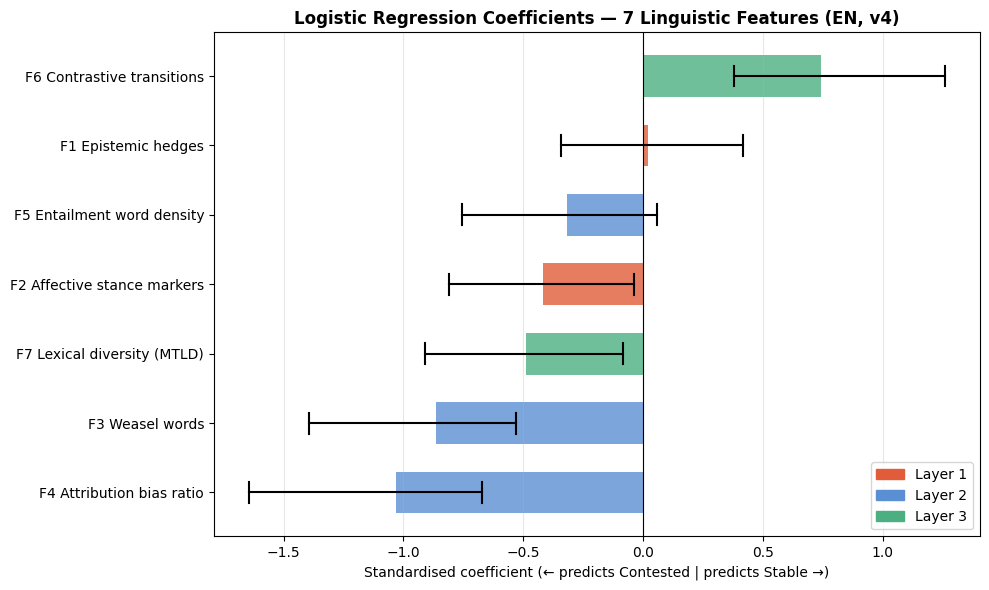

Saved: coefficients_v4.png


In [68]:
LAYER_COLORS = {'L1': '#E05C3A', 'L2': '#5B8FD4', 'L3': '#4CAF82'}

# ── Coefficient plot ───────────────────────────────────────────────────────────
coef_data = []
for i in ling_idx:
    f   = best_feats[i]
    lo  = np.percentile(coef_arr[:, i], 2.5)
    hi  = np.percentile(coef_arr[:, i], 97.5)
    c   = lr_boot.coef_[0][i]
    coef_data.append({'label': LABELS[f], 'coef': c, 'lo': lo, 'hi': hi, 'layer': LAYER_MAP[f]})

coef_data.sort(key=lambda x: x['coef'])

fig, ax = plt.subplots(figsize=(10, 6))
for j, d in enumerate(coef_data):
    color = LAYER_COLORS[d['layer']]
    ax.barh(j, d['coef'], color=color, alpha=0.8, height=0.6)
    ax.plot([d['lo'], d['hi']], [j, j], color='black', linewidth=1.5)
    ax.plot([d['lo'], d['lo']], [j-0.15, j+0.15], color='black', linewidth=1.5)
    ax.plot([d['hi'], d['hi']], [j-0.15, j+0.15], color='black', linewidth=1.5)

ax.set_yticks(range(len(coef_data)))
ax.set_yticklabels([d['label'] for d in coef_data], fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised coefficient (← predicts Contested | predicts Stable →)', fontsize=10)
ax.set_title('Logistic Regression Coefficients — 7 Linguistic Features (EN, v4)', fontsize=12, fontweight='bold')
legend_patches = [mpatches.Patch(color=c, label=f'Layer {l[-1]}') for l, c in LAYER_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('coefficients_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: coefficients_v4.png')


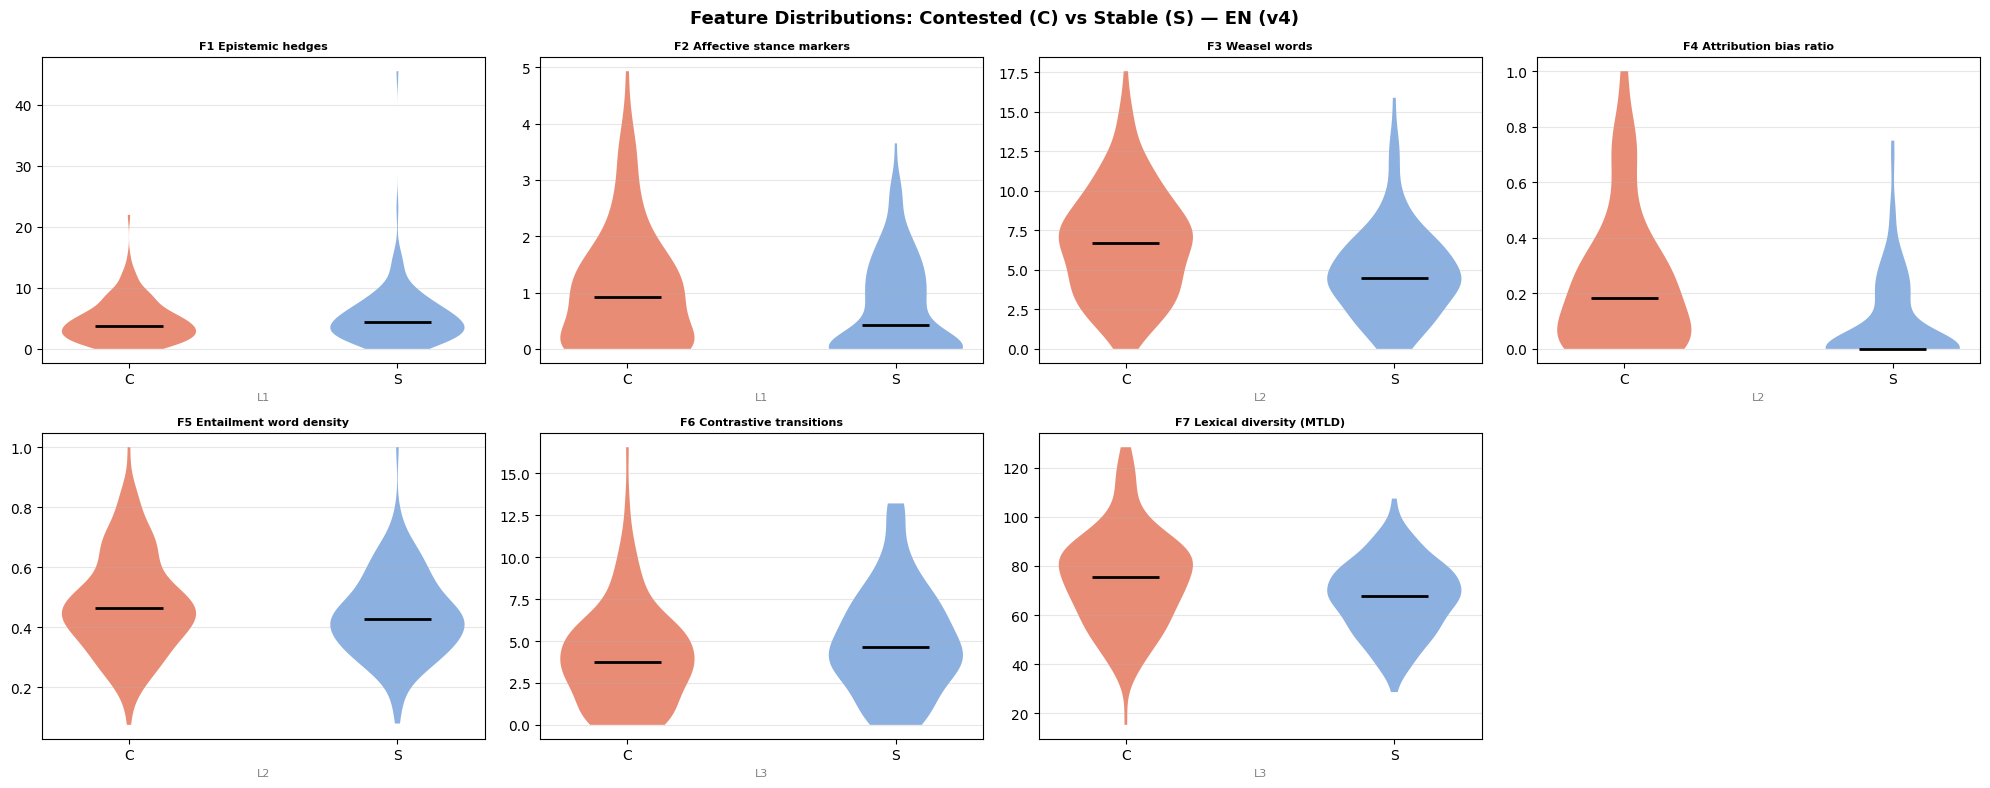

Saved: distributions_v4.png


In [69]:
# ── Violin plots (7 panels) ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes_flat = axes.flatten()

for ax, f in zip(axes_flat, LING_FEATURES):
    c_vals = df[df.label == 0][f].dropna()
    s_vals = df[df.label == 1][f].dropna()
    parts  = ax.violinplot([c_vals.values, s_vals.values],
                            positions=[0, 1], showmedians=True, showextrema=False)
    for body, color in zip(parts['bodies'], ['#E05C3A', '#5B8FD4']):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['C', 'S'], fontsize=10)
    ax.set_title(LABELS[f], fontsize=8, fontweight='bold')
    ax.set_xlabel(LAYER_MAP[f], fontsize=8, color='gray')
    ax.grid(axis='y', alpha=0.3)

# Hide unused panel
axes_flat[-1].set_visible(False)

fig.suptitle('Feature Distributions: Contested (C) vs Stable (S) — EN (v4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: distributions_v4.png')


## 11. Summary Table

In [72]:
def effect_size_label(r):
    r = abs(r)
    if r >= 0.5:   return 'large'
    elif r >= 0.3: return 'medium'
    elif r >= 0.1: return 'small'
    else:          return 'negligible'

print('=' * 90)
print('RESULTS SUMMARY — EN (v4, 7 features)')
print('=' * 90)
print(f'\nPairs loaded: {len(pairs)}')

print(f'\n{"Feature":<30} {"Dir":>5} {"Wilcoxon":>10} {"r_rb":>6} {"Effect":>10} {"Boot CI":>10}  Layer')
print('-' * 85)

for r in raw_results:
    f  = r['feature']
    i  = best_feats.index(f) if f in best_feats else -1
    if i < 0: continue
    lo    = np.percentile(coef_arr[:, i], 2.5)
    hi    = np.percentile(coef_arr[:, i], 97.5)
    ci_ok = 'stable' if (lo > 0 or hi < 0) else 'unstable'
    cm    = c_df[f].mean()
    sm    = s_df[f].mean()
    dir_ok = '✓' if ((cm > sm) == (PREDICTED[f] == 1)) else '✗'
    eff   = effect_size_label(r['r_rb'])
    print(f'{LABELS[f]:<30} {dir_ok:>5} {r["sig"]:>10} '
          f'{r["r_rb"]:>6.3f} {eff:>10} {ci_ok:>10}  {LAYER_MAP[f]}')

best_name = 'All 7 + topic controls'
if best_name in results:
    res = results[best_name]
    print(f'\nLogistic regression (all 7 + topic controls, 5-fold CV):')
    print(f'  F1 (macro) : {res["f1"]:.3f} ± {res["f1_std"]:.3f}')
    print(f'  Accuracy   : {res["acc"]:.3f}')
    print(f'  Baseline   : {base:.3f}')
    print(f'  vs baseline: {res["acc"] - base:+.3f}')

n_sig = sum(1 for r in raw_results if r['p_holm'] < 0.05)
n_dir = sum(1 for r in raw_results
            if (c_df[r['feature']].mean() > s_df[r['feature']].mean()) == (PREDICTED[r['feature']] == 1))
print(f'\nSignificant (Wilcoxon Holm p<.05) : {n_sig}/{len(LING_FEATURES)}')
print(f'Direction correct                  : {n_dir}/{len(LING_FEATURES)}')
print(f'Effect size: negligible r<.10 | small r≥.10 | medium r≥.30 | large r≥.50')

RESULTS SUMMARY — EN (v4, 7 features)

Pairs loaded: 143

Feature                          Dir   Wilcoxon   r_rb     Effect    Boot CI  Layer
-------------------------------------------------------------------------------------
F1 Epistemic hedges                ✗         ns  0.105      small   unstable  L1
F2 Affective stance markers        ✓          *  0.477     medium     stable  L1
F3 Weasel words                    ✓        ***  0.394     medium     stable  L2
F4 Attribution bias ratio          ✓         **  0.612      large     stable  L2
F5 Entailment word density         ✓          ~  0.186      small   unstable  L2
F6 Contrastive transitions         ✗          *  0.245      small     stable  L3
F7 Lexical diversity (MTLD)        ✓         **  0.294      small     stable  L3

Logistic regression (all 7 + topic controls, 5-fold CV):
  F1 (macro) : 0.715 ± 0.046
  Accuracy   : 0.717
  Baseline   : 0.500
  vs baseline: +0.217

Significant (Wilcoxon Holm p<.05) : 5/7
Direction cor

## 12. Permutation Test

In [73]:
n_permutations = 1000
perm_sig_counts = []
rng = np.random.default_rng(seed=42)  # fixed seed for reproducibility

for _ in range(n_permutations):
    perm_diffs = diff_df[LING_FEATURES].copy()
    # Randomly flip signs row-wise (each pair independently)
    signs = rng.choice([-1, 1], size=len(perm_diffs))
    perm_diffs = perm_diffs.multiply(signs, axis=0)

    p_vals_perm = []
    for f in LING_FEATURES:
        vals = perm_diffs[f].dropna()
        if len(vals) < 5: continue
        _, p = wilcoxon(vals)
        p_vals_perm.append(p)
    if not p_vals_perm: continue
    _, p_holm_perm, _, _ = multipletests(p_vals_perm, method='holm')
    perm_sig_counts.append(sum(p < 0.05 for p in p_holm_perm))

real_sig = n_sig
p_perm   = np.mean(np.array(perm_sig_counts) >= real_sig)
print(f'Observed significant features : {real_sig}/{len(LING_FEATURES)}')
print(f'Permutation mean under null   : {np.mean(perm_sig_counts):.2f}')
print(f'Permutation p-value           : {p_perm:.4f}')

Observed significant features : 5/7
Permutation mean under null   : 0.05
Permutation p-value           : 0.0000


## 13. AUC (ROC)

In [74]:
from sklearn.metrics import roc_auc_score

d   = df_model[LING_FEATURES + ['label']].dropna()
X   = StandardScaler().fit_transform(d[LING_FEATURES].values)
y   = d['label'].values

cv_auc  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_auc  = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
aucs    = cross_val_score(lr_auc, X, y, cv=cv_auc, scoring='roc_auc')
accs    = cross_val_score(lr_auc, X, y, cv=cv_auc, scoring='accuracy')

print(f'AUC (5-fold CV)  : {aucs.mean():.3f} ± {aucs.std():.3f}')
print(f'Accuracy (5-fold): {accs.mean():.3f} ± {accs.std():.3f}')
print(f'Baseline (random): 0.500')


AUC (5-fold CV)  : 0.822 ± 0.024
Accuracy (5-fold): 0.746 ± 0.045
Baseline (random): 0.500
